<a href="https://www.kaggle.com/code/harshkumar18999/bio-medical-signal-classification?scriptVersionId=259183303" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [2]:
# import dependencies
import os
import glob
import fnmatch
import pandas as pd
import numpy as np
import librosa #To deal with sound
import librosa.display
import matplotlib.pyplot as plt
import IPython.display as ipd
import tensorflow as tf

2025-08-31 08:17:52.484145: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1756628272.510819     178 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1756628272.518606     178 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [3]:
dataset = "/kaggle/input/heart-sound-database/heart_sound"
train_data = "/kaggle/input/heart-sound-database/heart_sound/train"
test_data = "/kaggle/input/heart-sound-database/heart_sound/val"

In [4]:
print( "Number of healty sounds files : {}".format(len(os.listdir("/kaggle/input/heart-sound-database/heart_sound/train/healthy")))) #number of healthy training sounds
print("Number of unhealty sounds files : {}".format(len(os.listdir("/kaggle/input/heart-sound-database/heart_sound/train/unhealthy")))) #number of unhelathy training sounds 

Number of healty sounds files : 2575
Number of unhealty sounds files : 665


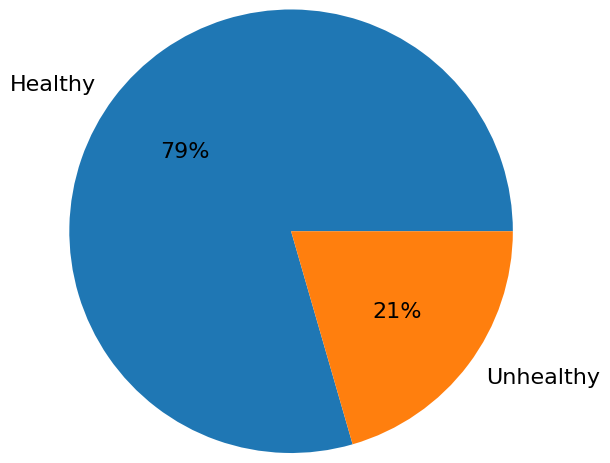

In [5]:
# pie chart of counting of healthy sounds and unhealthy sounds
x = np.array([len(os.listdir("/kaggle/input/heart-sound-database/heart_sound/train/healthy")),len(os.listdir("/kaggle/input/heart-sound-database/heart_sound/train/unhealthy"))])
labels = ['Healthy', 'Unhealthy']
colors = {'Healthy': 'chartreuse','Unhealthy': 'teal' }
plt.plot(figsize=(10, 10))
plt.pie(x, labels = labels, autopct = '%.0f%%', radius= 1.5, textprops={'fontsize': 16})
plt.show()

# **Data Pre-Processing**

In [6]:
# Choose random soud from healthy folder
random_healthy= np.random.randint(0,len(os.listdir("/kaggle/input/heart-sound-database/heart_sound/train/healthy"))) 
healthy_sound = os.listdir("/kaggle/input/heart-sound-database/heart_sound/train/healthy/")[random_healthy]
healthy_sound_address = "/kaggle/input/heart-sound-database/heart_sound/train/healthy/"+healthy_sound
healthy_sound_sample,sample_rate = librosa.load(healthy_sound_address)
ipd.Audio(healthy_sound_sample,rate=sample_rate)

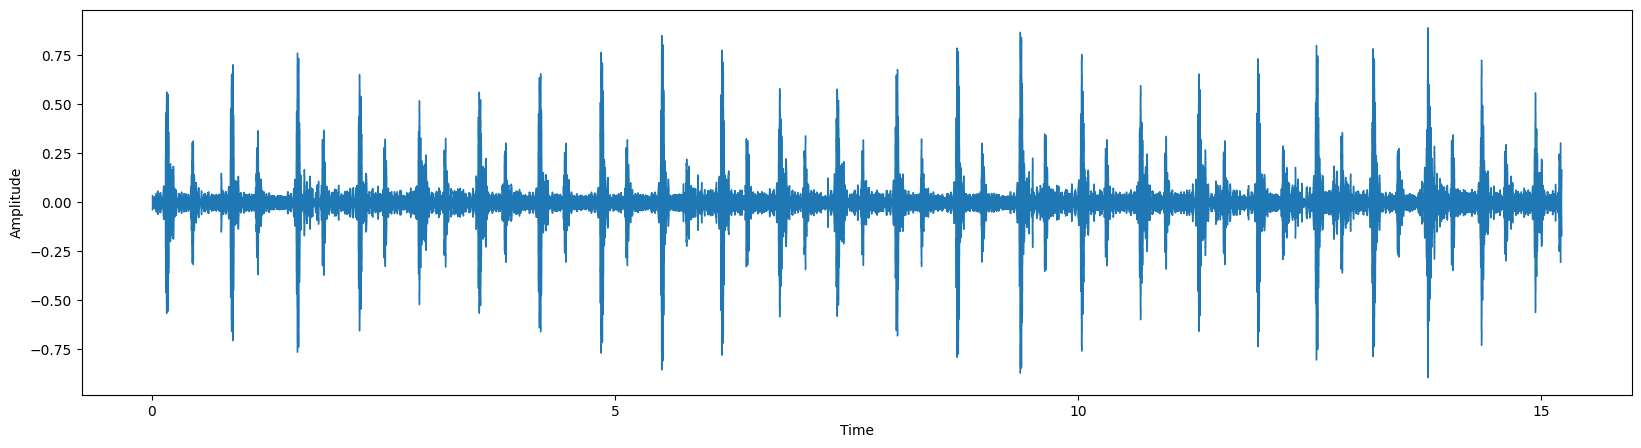

In [7]:
plt.figure(figsize=(20, 5))
librosa.display.waveshow(healthy_sound_sample, sr=sample_rate)
plt.xlabel("Time")
plt.ylabel("Amplitude")
plt.show()

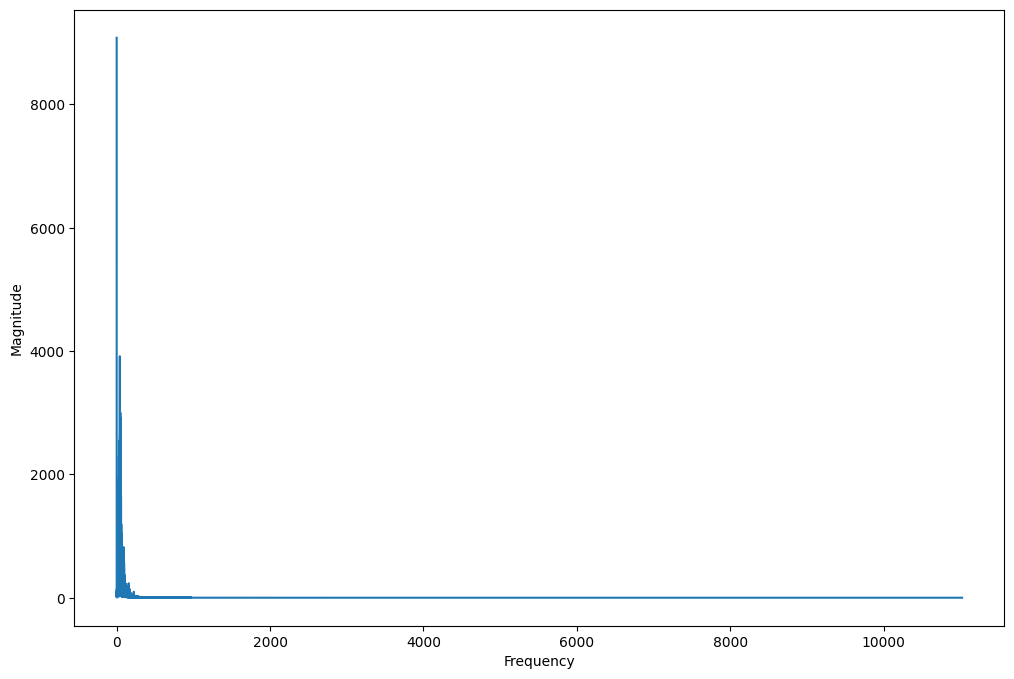

In [8]:
fft_healthy = np.fft.fft(healthy_sound_sample)
magnitude_healthy = np.abs(fft_healthy)
freq_healthy = np.linspace(0,sample_rate, len(magnitude_healthy)) 
half_freq = freq_healthy[:int(len(freq_healthy)/2)]
half_magnitude = magnitude_healthy[:int(len(freq_healthy)/2)]

plt.figure(figsize=(12,8))
plt.plot(half_freq,half_magnitude)
plt.xlabel("Frequency")
plt.ylabel("Magnitude")
plt.show()


STFT hop length duration is: 0.023219954648526078s
STFT window duration is: 0.09287981859410431s


Text(0.5, 1.0, 'Spectrogram')

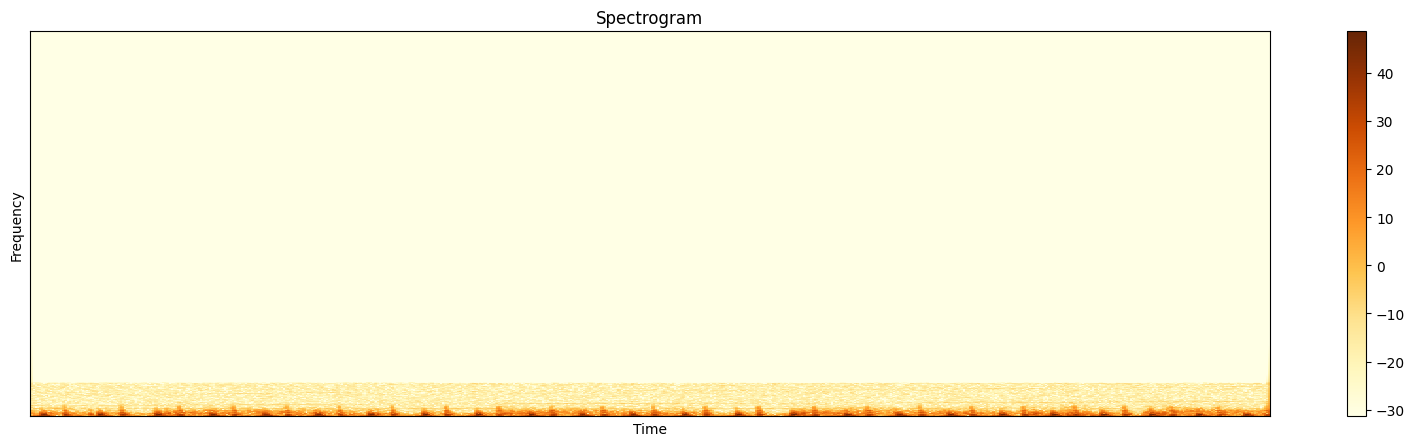

In [9]:
# STFT -> spectrogram
hop_length = 512 # in num. of samples
n_fft = 2048 # window in num. of samples

# calculate duration hop length and window in seconds
hop_length_duration = float(hop_length)/sample_rate
n_fft_duration = float(n_fft)/sample_rate

print("STFT hop length duration is: {}s".format(hop_length_duration))
print("STFT window duration is: {}s".format(n_fft_duration))

# perform stft
stft_healthy = librosa.stft(healthy_sound_sample, n_fft=n_fft, hop_length=hop_length)

# calculate abs values on complex numbers to get magnitude
spectrogram = np.abs(stft_healthy)
log_spectrogram = librosa.amplitude_to_db(spectrogram)

# display spectrogram
plt.figure(figsize=(20,5))
librosa.display.specshow(log_spectrogram, sr=sample_rate, hop_length=hop_length)
plt.xlabel("Time")
plt.ylabel("Frequency")
plt.colorbar()
plt.set_cmap("YlOrBr")
plt.title("Spectrogram")


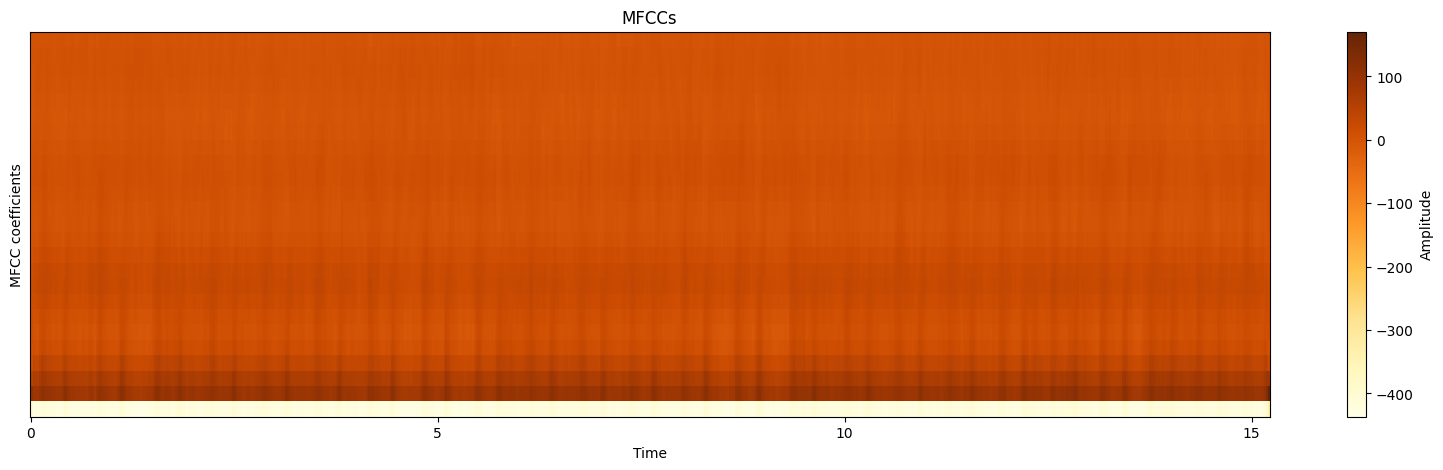

In [10]:
# Extract 25 MFCCs
MFCCs = librosa.feature.mfcc(
    y=healthy_sound_sample, 
    sr=sample_rate, 
    n_fft=n_fft, 
    hop_length=hop_length, 
    n_mfcc=25
)

# Display MFCCs
plt.figure(figsize=(20, 5))
librosa.display.specshow(
    MFCCs, 
    sr=sample_rate, 
    hop_length=hop_length, 
    x_axis="time", 
    cmap="YlOrBr"
)
plt.colorbar(label="Amplitude")
plt.xlabel("Time")
plt.ylabel("MFCC coefficients")
plt.title("MFCCs")
plt.show()

In [11]:
# Choose random soud from unhealthy folder
random_unhealthy= np.random.randint(0,len(os.listdir("/kaggle/input/heart-sound-database/heart_sound/train/unhealthy"))) 
unhealthy_sound = os.listdir("/kaggle/input/heart-sound-database/heart_sound/train/unhealthy")[random_unhealthy]
unhealthy_sound_address = "/kaggle/input/heart-sound-database/heart_sound/train/unhealthy/"+unhealthy_sound
unhealthy_sound_sample,sample_rate = librosa.load(unhealthy_sound_address)
ipd.Audio(unhealthy_sound_sample,rate=sample_rate)


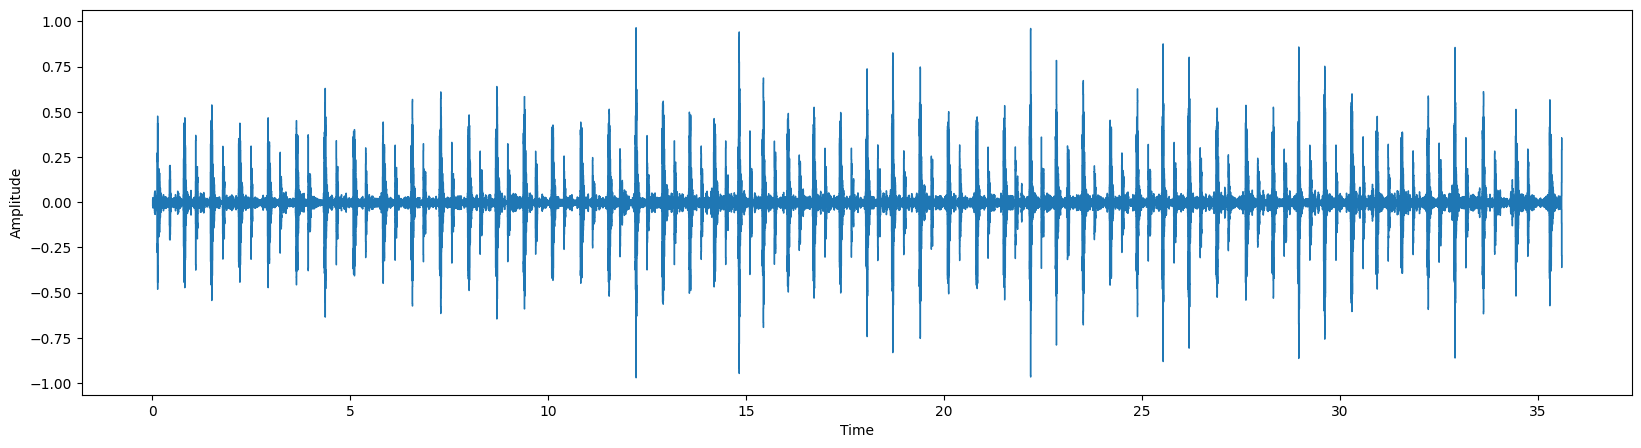

In [12]:
# visualize wave of sounds sample
plt.figure(figsize=(20,5))
librosa.display.waveshow(unhealthy_sound_sample, sr = sample_rate)
plt.xlabel("Time")
plt.ylabel("Amplitude")
plt.show()


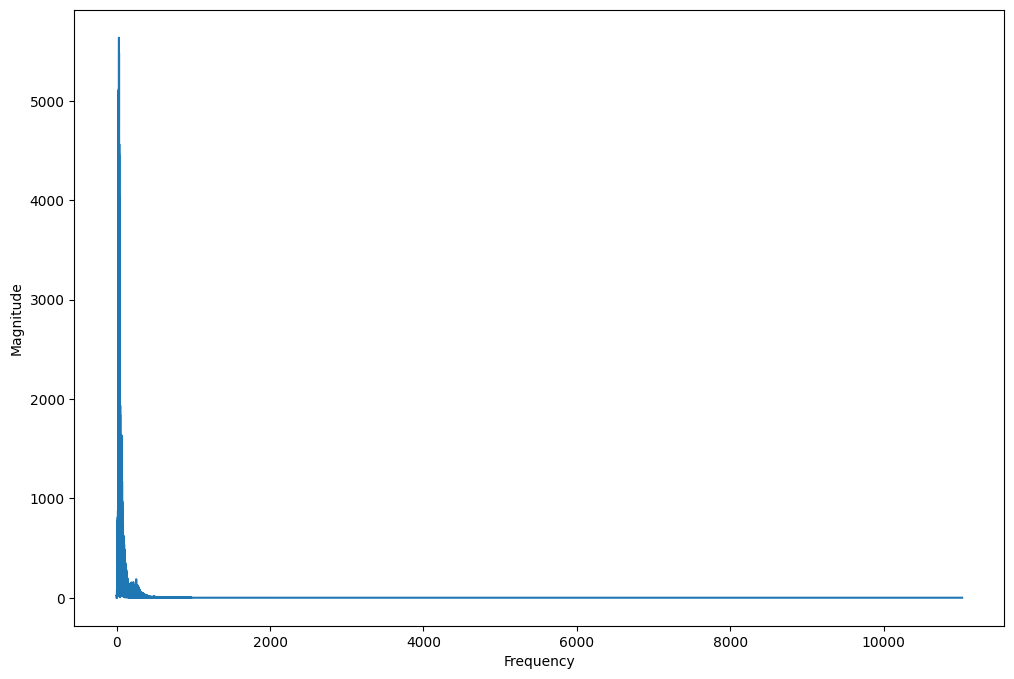

In [13]:
fft_unhealthy = np.fft.fft(unhealthy_sound_sample)
magnitude_unhealthy = np.abs(fft_unhealthy)
freq_unhealthy = np.linspace(0,sample_rate, len(magnitude_unhealthy)) 
half_freq = freq_unhealthy[:int(len(freq_unhealthy)/2)]
half_magnitude = magnitude_unhealthy[:int(len(freq_unhealthy)/2)]

plt.figure(figsize=(12,8))
plt.plot(half_freq,half_magnitude)
plt.xlabel("Frequency")
plt.ylabel("Magnitude")
plt.show()


STFT hop length duration is: 0.023219954648526078s
STFT window duration is: 0.09287981859410431s


Text(0.5, 1.0, 'Spectrogram')

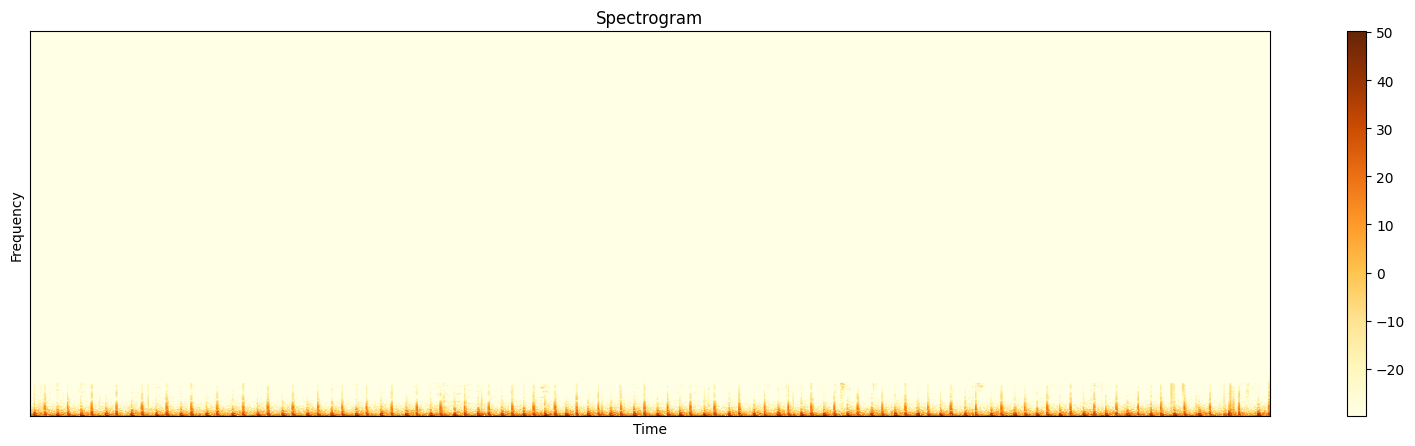

In [14]:
# STFT -> spectrogram
hop_length = 512 # in num. of samples
n_fft = 2048 # window in num. of samples

# calculate duration hop length and window in seconds
hop_length_duration = float(hop_length)/sample_rate
n_fft_duration = float(n_fft)/sample_rate

print("STFT hop length duration is: {}s".format(hop_length_duration))
print("STFT window duration is: {}s".format(n_fft_duration))

# perform stft
stft_unhealthy = librosa.stft(unhealthy_sound_sample, n_fft=n_fft, hop_length=hop_length)

# calculate abs values on complex numbers to get magnitude
spectrogram = np.abs(stft_unhealthy)
log_spectrogram = librosa.amplitude_to_db(spectrogram)

# display spectrogram
plt.figure(figsize=(20,5))
librosa.display.specshow(log_spectrogram, sr=sample_rate, hop_length=hop_length)
plt.xlabel("Time")
plt.ylabel("Frequency")
plt.colorbar()
plt.set_cmap("YlOrBr")
plt.title("Spectrogram")


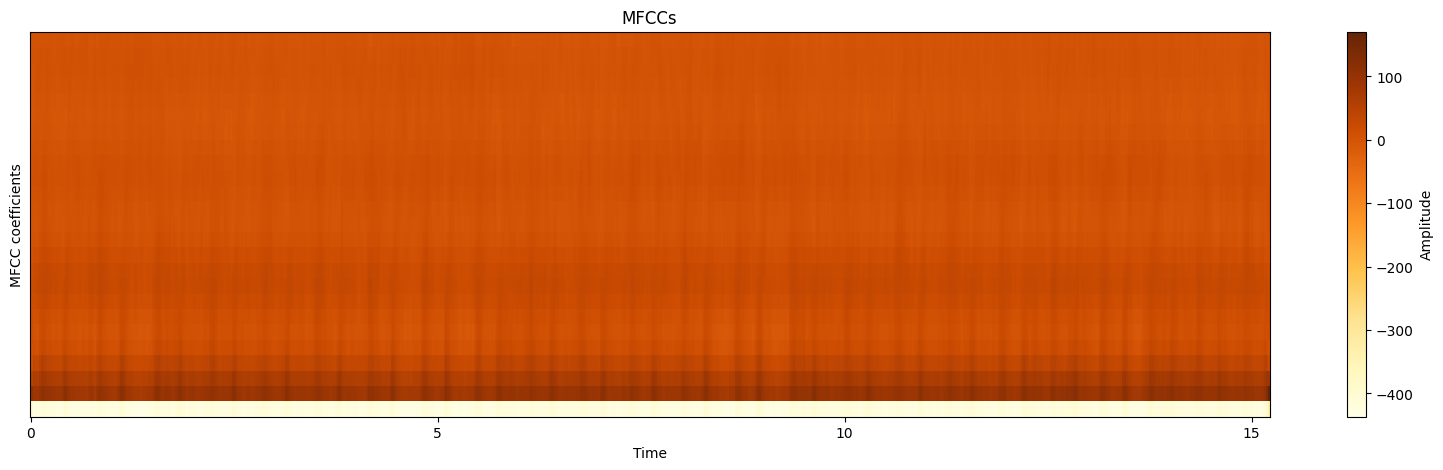

In [15]:
# Extract 25 MFCCs
MFCCs = librosa.feature.mfcc(
    y=healthy_sound_sample, 
    sr=sample_rate, 
    n_fft=n_fft, 
    hop_length=hop_length, 
    n_mfcc=25
)

# Display MFCCs
plt.figure(figsize=(20, 5))
librosa.display.specshow(
    MFCCs, 
    sr=sample_rate, 
    hop_length=hop_length, 
    x_axis="time", 
    cmap="YlOrBr"
)
plt.colorbar(label="Amplitude")
plt.xlabel("Time")
plt.ylabel("MFCC coefficients")
plt.title("MFCCs")
plt.show()

In [16]:
def load_file_data(folder, file_names, duration=10, sr=22050):
    input_length = sr * duration
    data = []
    
    for file_name in file_names:
        try:
            sound_file = folder + file_name
            
            # Load with librosa
            X, sr = librosa.load(sound_file, sr=sr, duration=duration, res_type='kaiser_fast') 
            dur = librosa.get_duration(y=X, sr=sr)
            
            # Pad audio if too short
            if round(dur) < duration:
                X = librosa.util.fix_length(data=X, size=input_length)
            
            # Extract normalized MFCC feature
            mfccs = np.mean(librosa.feature.mfcc(y=X, sr=sr, n_mfcc=25).T,axis=0)
        
        except Exception as e:
            print("Error encountered while parsing file:", file_name, "|", str(e))
            continue  # skip to next file if error
        
        feature = np.array(mfccs).reshape([-1, 1])
        data.append(feature)
    
    return data


## **Encoding** 

In [17]:
# simple encoding of categories, limited to 3 types
from sklearn.model_selection import train_test_split
from sklearn import preprocessing

# Map label text to integer
CLASSES = ['healthy','unhealthy']
NB_CLASSES=len(CLASSES)

# Map integer value to text labels
label_to_int = {k:v for v,k in enumerate(CLASSES)}
print (label_to_int)
print (" ")
# map integer to label text
int_to_label = {v:k for k,v in label_to_int.items()}
print(int_to_label)

{'healthy': 0, 'unhealthy': 1}
 
{0: 'healthy', 1: 'unhealthy'}


In [49]:
!pip install resampy

## **Loading processed data**

In [18]:
SAMPLE_RATE = 22050
# seconds
MAX_SOUND_CLIP_DURATION=10

healthy_files = fnmatch.filter(os.listdir("/kaggle/input/heart-sound-database/heart_sound/train/healthy/"), '*.wav')
healthy_sounds = load_file_data (folder="/kaggle/input/heart-sound-database/heart_sound/train/healthy/", file_names = healthy_files, duration=MAX_SOUND_CLIP_DURATION)
healthy_labels = [0 for items in healthy_files]

print ("loaded dataset")


loaded dataset


In [19]:
unhealthy_files = fnmatch.filter(os.listdir("/kaggle/input/heart-sound-database/heart_sound/train/unhealthy/"), '*.wav')
unhealthy_sounds = load_file_data(folder="/kaggle/input/heart-sound-database/heart_sound/train/unhealthy/",file_names=unhealthy_files, duration=MAX_SOUND_CLIP_DURATION)
unhealthy_labels = [1 for items in unhealthy_sounds]

In [20]:
# test files
val_healthy_files = fnmatch.filter(os.listdir("/kaggle/input/heart-sound-database/heart_sound/val/healthy/"), '*.wav')
val_healthy_sounds = load_file_data(folder="/kaggle/input/heart-sound-database/heart_sound/val/healthy/",file_names=val_healthy_files, duration=MAX_SOUND_CLIP_DURATION)
val_healthy_labels = [0 for items in val_healthy_sounds]

val_unhealthy_files = fnmatch.filter(os.listdir("/kaggle/input/heart-sound-database/heart_sound/val/unhealthy/"), '*.wav')
val_unhealthy_sounds = load_file_data(folder="/kaggle/input/heart-sound-database/heart_sound/val/unhealthy/",file_names=val_unhealthy_files, duration=MAX_SOUND_CLIP_DURATION)
val_unhealthy_labels = [1 for items in val_unhealthy_sounds]

print ("loaded test dataset")

loaded test dataset


## **concatenation**

In [21]:
# concatenate both healthy & unhealthy data

x_data = np.concatenate((healthy_sounds, unhealthy_sounds))
y_data = np.concatenate((healthy_labels,unhealthy_labels))

test_x = np.concatenate((val_healthy_sounds,val_unhealthy_sounds))
test_y = np.concatenate((val_healthy_labels,val_unhealthy_labels))

print ("combined training data record: ",len(y_data), len(test_y))

combined training data record:  3240 301


In [22]:
# shuffle - whether or not to shuffle the data before splitting. If shuffle=False then stratify must be None.
# random_state is the seed used by the random number generator; If RandomState instance, random_state is the random number generator; If None, the random number generator is the RandomState instance used by np.random.

seed = 100
# split data into Train, Validation and Test
x_train, x_test, y_train, y_test = train_test_split(x_data, y_data, train_size=0.8, random_state=seed, shuffle=True)
x_train, x_val, y_train, y_val = train_test_split(x_train, y_train, train_size=0.8, random_state=seed, shuffle=True)

# One-Hot encoding for classes
y_train = np.array(tf.keras.utils.to_categorical(y_train, len(CLASSES)))
y_test = np.array(tf.keras.utils.to_categorical(y_test, len(CLASSES)))
y_val = np.array(tf.keras.utils.to_categorical(y_val, len(CLASSES)))
test_y=np.array(tf.keras.utils.to_categorical(test_y, len(CLASSES)))

In [23]:
# define class weights for highly imbalance dataset
TRAIN_IMG_COUNT = 3240
COUNT_0 = 2575  #healthy
COUNT_1 = 665 #unhealthy
weight_for_0 = TRAIN_IMG_COUNT / (2 * COUNT_0)
weight_for_1 = TRAIN_IMG_COUNT / (2 * COUNT_1)
class_weight = {0: weight_for_0, 1: weight_for_1}
class_weight

{0: 0.629126213592233, 1: 2.43609022556391}

# **LSTM Model Architecture**

In [24]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Activation, Flatten, LSTM, Bidirectional
from tensorflow.keras.layers import Convolution2D, MaxPooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping,ReduceLROnPlateau,ModelCheckpoint,TensorBoard,ProgbarLogger

#from tensorflow.keras.utils import np_utils
from sklearn import metrics 
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.preprocessing import LabelEncoder
import itertools

In [26]:
loss = tf.keras.losses.BinaryFocalCrossentropy(
    apply_class_balancing=False,
    alpha=0.25,
    gamma=2.0,
    from_logits=False,
    label_smoothing=0.0,
    axis=-1,
    reduction='sum_over_batch_size',
    name='binary_focal_crossentropy'
)

In [46]:
# define model architecture 
from tensorflow.keras.metrics import AUC, Precision, Recall

model = Sequential()
model.add(Bidirectional(LSTM(128, dropout=0.05, recurrent_dropout=0.20, return_sequences=True), input_shape = (25,1)))
model.add(Dense(128, activation='relu'))
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.4))
model.add(Dense(32, activation='relu'))
model.add(Dense(32, activation='relu'))
model.add(Dropout(0.4))
model.add(Dense(32, activation='relu'))
model.add(Flatten())

model.add(Dense(2, activation='sigmoid'))

model.compile(loss=loss, 
              optimizer='Adamax', 
              metrics=[
                              AUC(name="auc", curve="ROC"), 
                              AUC(name="pr_auc", curve="PR"),  # Precision-Recall AUC
                              Recall(name="recall"),
                              Precision(name="precision")
                              ]
)


model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional_4 (Bidirectional) │ (None, 25, 256)        │       133,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 25, 128)        │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 25, 64)         │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 25, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 25, 32)         │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 25, 32)         │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 25, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 25, 32)         │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 800)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 2)              │         1,602 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 180,066 (703.38 KB)

 Trainable params: 180,066 (703.38 KB)

 Non-trainable params: 0 (0.00 B)

# **Model Training**

In [47]:
# training

early_stop = EarlyStopping(
    monitor='val_recall',       # monitor validation loss
    patience=15,               # stop after 5 epochs of no improvement
    mode="max"
)

# 2. Save the best model during training
checkpoint = ModelCheckpoint(
    filepath='best_model.keras', # file to save model
    monitor='val_recall',       # metric to monitor
    save_best_only=True,      # only save when val_loss improves
    mode='max',               # 'min' because we want lowest val_loss
    verbose=1
)

history=model.fit(x_train, y_train, 
                  batch_size=16, 
                  epochs=100,
                  validation_data=(x_val, y_val),
                  callbacks=[early_stop, checkpoint],
                  class_weight = class_weight
)

Epoch 1/100
130/130 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - auc: 0.6424 - loss: 0.1633 - pr_auc: 0.6234 - precision: 0.6042 - recall: 0.6371
Epoch 1: val_recall improved from -inf to 0.75723, saving model to best_model.keras
130/130 ━━━━━━━━━━━━━━━━━━━━ 22s 67ms/step - auc: 0.6428 - loss: 0.1632 - pr_auc: 0.6236 - precision: 0.6045 - recall: 0.6373 - val_auc: 0.7715 - val_loss: 0.1482 - val_pr_auc: 0.7802 - val_precision: 0.6968 - val_recall: 0.7572
Epoch 2/100
130/130 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - auc: 0.7890 - loss: 0.1421 - pr_auc: 0.7844 - precision: 0.7172 - recall: 0.7391
Epoch 2: val_recall improved from 0.75723 to 0.76686, saving model to best_model.keras
130/130 ━━━━━━━━━━━━━━━━━━━━ 7s 51ms/step - auc: 0.7890 - loss: 0.1421 - pr_auc: 0.7844 - precision: 0.7172 - recall: 0.7390 - val_auc: 0.8559 - val_loss: 0.1214 - val_pr_auc: 0.8681 - val_precision: 0.7197 - val_recall: 0.7669
Epoch 3/100
129/130 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - auc: 0.8334 - loss: 0.1355 - pr_auc: 0.839

# **Evaluation**

<Axes: >

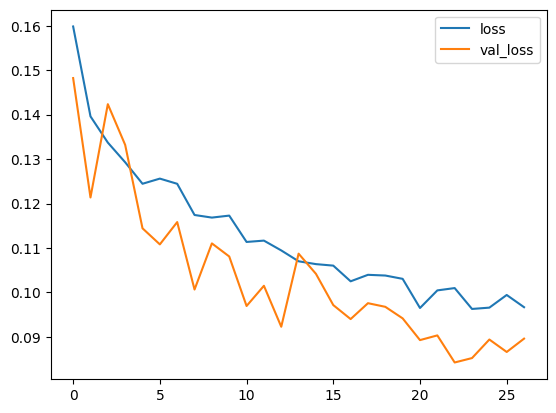

In [49]:
# visualize loss

losses = pd.DataFrame(model.history.history)
losses[['loss','val_loss']].plot()

<Axes: >

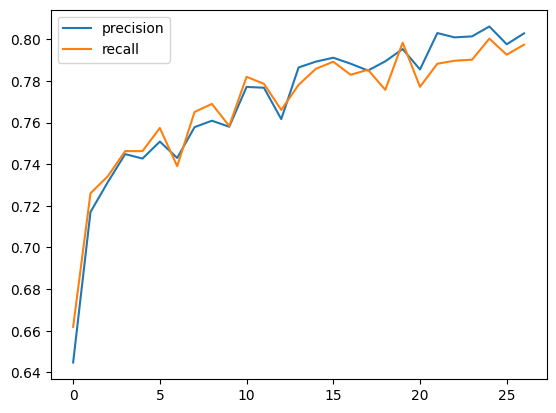

In [50]:
# visulaize accuracy
losses[['precision','recall']].plot()

In [51]:
from tensorflow.keras.models import load_model
model = load_model("/kaggle/working/best_model.keras")

# make a prediction
y_pred = model.predict(x_test, batch_size=5)

#check scores
scores = model.evaluate(x_test, y_test)
print ("Model evaluation accuracy: ", round(scores[1]*100),"%")

130/130 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step
21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - auc: 0.9206 - loss: 0.1087 - pr_auc: 0.9116 - precision: 0.8423 - recall: 0.8951
Model evaluation accuracy:  94 %


In [52]:
y_pred = model.predict(x_test, batch_size=5)

# Extract probability for positive class
y_prob = y_pred[:, 1]

# Try custom threshold
threshold = 0.5
y_pred = (y_prob >= threshold).astype(int)

130/130 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step


In [53]:
target_names = ["Healthy", "Unhealthy"]
print(classification_report(y_test.argmax(axis=1), y_pred, target_names = target_names))

              precision    recall  f1-score   support

     Healthy       0.95      0.86      0.90       527
   Unhealthy       0.57      0.82      0.67       121

    accuracy                           0.85       648
   macro avg       0.76      0.84      0.79       648
weighted avg       0.88      0.85      0.86       648



In [54]:
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score, roc_curve

# Precision, Recall, F1
precision = precision_score(y_test.argmax(axis=1), y_pred)
recall = recall_score(y_test.argmax(axis=1), y_pred)
f1 = f1_score(y_test.argmax(axis=1), y_pred)
conf_matrix = confusion_matrix(y_test.argmax(axis=1), y_pred)

print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Precision: 0.5657142857142857
Recall: 0.8181818181818182
F1 Score: 0.668918918918919


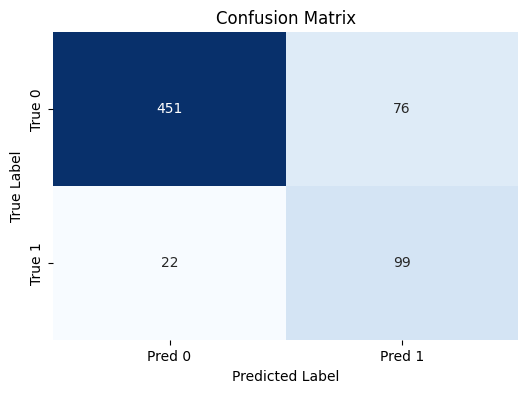

In [55]:
import seaborn as sns
# Plot confusion matrix
plt.figure(figsize=(6,4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Pred 0', 'Pred 1'],
            yticklabels=['True 0', 'True 1'])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

130/130 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
AUC-ROC Score: 0.9111844684554706


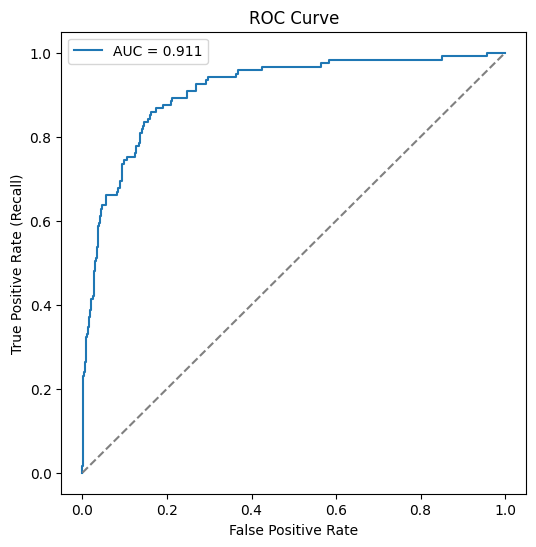

In [66]:
# 1. Calculate AUC score
y_pred = model.predict(x_test, batch_size=5)
auc_score = roc_auc_score(y_test, y_pred)
print("AUC-ROC Score:", auc_score)


# 2. Get ROC curve values
y_pred_proba = y_pred[:, 1]
fpr, tpr, thresholds = roc_curve(y_test.argmax(axis=1), y_pred_proba)

# 3. Plot ROC curve
plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.3f}")
plt.plot([0,1], [0,1], linestyle='--', color='gray')  # random baseline
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curve")
plt.legend()
plt.show()
